#  Vacuum Rabi Oscillations and Ground State Analysis in the Jaynes–Cummings Model

This code explores the **Jaynes–Cummings model**, describing the interaction between a two-level atom and a single-mode quantized electromagnetic field (cavity). We simulate both the dynamics and the ground-state properties under different interaction Hamiltonians.

---

##  Parameters and Initial Setup

We define the following constants and initial state:
- Cavity frequency $ \omega_c = \pi $
- Atom transition frequency $ \omega_a = \pi $
- Coupling strength $ g = 0.05\pi $
- Initial state: vacuum state in the cavity and atom in the excited state $ |0\rangle \otimes |1\rangle $

---

##  Time Evolution: Vacuum Rabi Oscillations

We simulate the time evolution of the atom-cavity system using `qutip.sesolve`. The total Hamiltonian is:
$
H = \omega_c a^\dagger a + \omega_a \sigma^\dagger \sigma + g (a^\dagger \sigma + a \sigma^\dagger)
$

We plot the occupation probabilities:
-  Cavity photon number expectation $ \langle a^\dagger a \rangle $
-  Atom excited state population $ \langle \sigma^\dagger \sigma \rangle $

These oscillations are known as **vacuum Rabi oscillations**.

---

##  Ground State Analysis: Standard Jaynes–Cummings Coupling

We now examine the ground state properties of the system as the coupling strength \( g \) varies. The interaction Hamiltonian remains:
$
H_1 = a^\dagger \sigma + a \sigma^\dagger
$

For each value of $ g $, we:
- Compute the ground state of the Hamiltonian
- Extract the expectation values of the cavity and atomic excitations

---

##  Modified Coupling: Beyond Rotating Wave Approximation (RWA)

We now analyze the system with the **full interaction Hamiltonian**, including counter-rotating terms:
$
H_1 = (a^\dagger + a)(\sigma + \sigma^\dagger)
$

This goes beyond the RWA and includes non-energy-conserving processes. The same analysis is repeated:
- Compute ground states for varying $ g $
- Extract expectation values

 **Plots:** Show how the excitation distribution changes compared to the RWA case.


C:\Users\HP\anaconda3\lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
C:\Users\HP\anaconda3\lib\site-packages\qutip\core\qobj.py:1716: UserWarning: Ground state may be degenerate.
  warnings.warn("Ground state may be degenerate.", UserWarning)


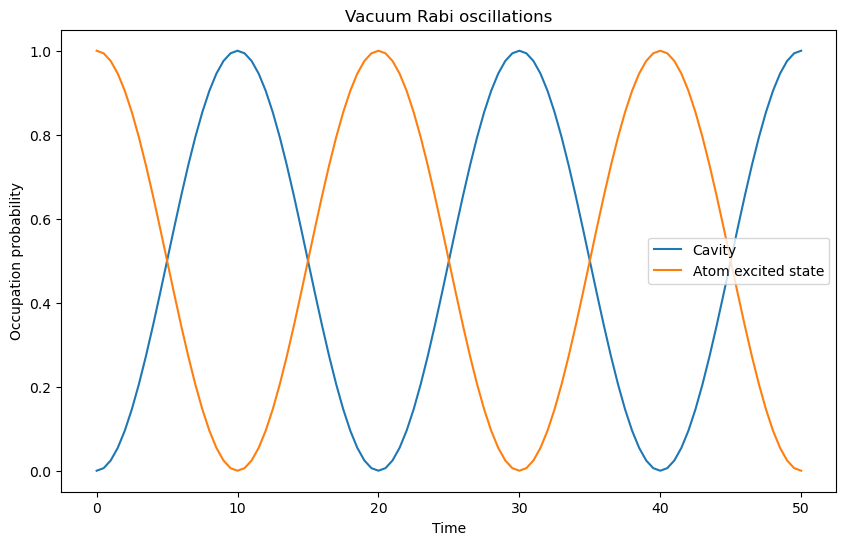

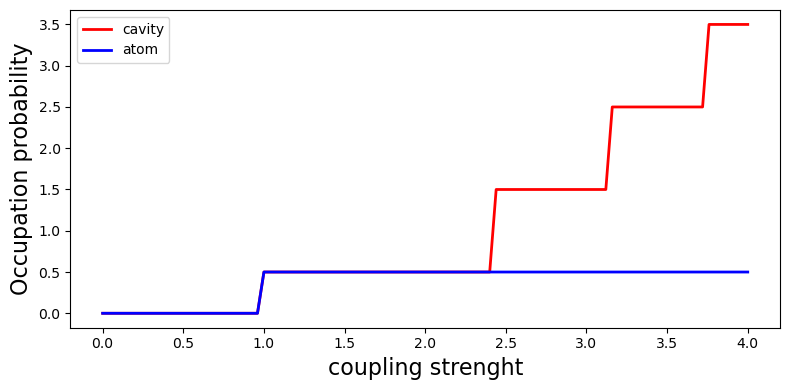

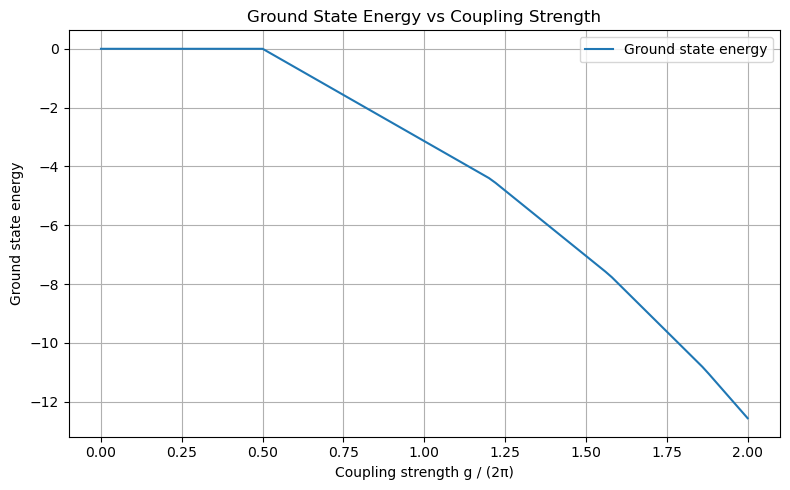

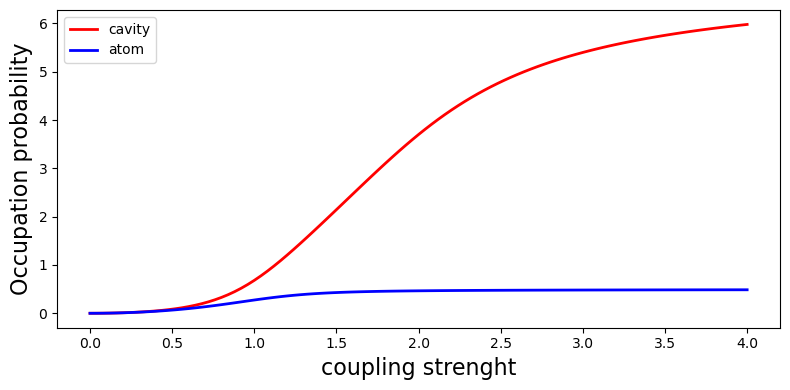

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from qutip import (basis,destroy,sesolve,qeye,tensor,expect)

wc =  np.pi  # cavity frequency
wa =  np.pi  # atom frequency
g = 0.05 * np.pi  # coupling strength
N = 10  # number of cavity fock states
n_th_a = 0.0 


tlist = np.linspace(0, 50, 101)

psi0 = tensor(basis(N,0),basis(2,1))

a = tensor(destroy(N),qeye(2))
c = tensor(qeye(N),destroy(2))

H =  H = wc * a.dag() * a + wa * c.dag() * c + \
        g * (a.dag() * c + a * c.dag())

result = sesolve(H, psi0, tlist, [a.dag()*a, c.dag()*c])

n_c = result.expect[0]
n_a = result.expect[1]

fig, axes = plt.subplots(1, 1, figsize=(10, 6))

axes.plot(tlist, n_c, label="Cavity")
axes.plot(tlist, n_a, label="Atom excited state")
axes.legend(loc=0)
axes.set_xlabel("Time")
axes.set_ylabel("Occupation probability")
axes.set_title("Vacuum Rabi oscillations");

H0 = wc * a.dag() * a + wa * c.dag() * c

# interaction Hamiltonian
H1 = a.dag() * c + a * c.dag()


g_vec = np.linspace(0, 2.0, 101) * 2 * np.pi  # coupling strength vector

n_c_list = []
n_a_list = []
energy_list = []
for g in g_vec:
    H = H0 + g * H1
    gnd_energy, gnd_state = H.groundstate()
    
    # Expectation values in ground state
    n_c_list.append(expect(a.dag() * a, gnd_state))
    n_a_list.append(expect(c.dag() * c, gnd_state))
    energy_list.append(gnd_energy)

fig, axes = plt.subplots(1, 1, sharex=True, figsize=(8, 4))

axes.plot(g_vec / ( np.pi), n_c_list, "r", linewidth=2, label="cavity")
axes.plot(g_vec / ( np.pi), n_a_list, "b", linewidth=2, label="atom")
axes.set_ylabel("Occupation probability", fontsize=16)
axes.set_xlabel("coupling strenght", fontsize=16)
axes.legend(loc=0)

fig.tight_layout()

plt.figure(figsize=(8, 5))
plt.plot(g_vec / (2 * np.pi), energy_list, label="Ground state energy")
plt.xlabel("Coupling strength g / (2π)")
plt.ylabel("Ground state energy")
plt.title("Ground State Energy vs Coupling Strength")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

H1 = (a.dag() + a) * (c + c.dag())


g_vec2 = np.linspace(0, 2.0, 101) * 2 * np.pi  # coupling strength vector

n_c_list2 = []
n_a_list2 = []

for g in g_vec2:
    H = H0 + g * H1
    gnd_energy2, gnd_state2 = H.groundstate()
    
    # Expectation values in ground state
    n_c_list2.append(expect(a.dag() * a, gnd_state2))
    n_a_list2.append(expect(c.dag() * c, gnd_state2))

fig, axes = plt.subplots(1, 1, sharex=True, figsize=(8, 4))

axes.plot(g_vec / ( np.pi), n_c_list2, "r", linewidth=2, label="cavity")
axes.plot(g_vec / ( np.pi), n_a_list2, "b", linewidth=2, label="atom")
axes.set_ylabel("Occupation probability", fontsize=16)
axes.set_xlabel("coupling strenght", fontsize=16)
axes.legend(loc=0)

fig.tight_layout()


# Jaynes–Cummings Model with Dissipation and Ground State Analysis

This notebook extends the Jaynes–Cummings model (JCM) simulation by including **dissipative dynamics** using the Lindblad master equation. It also explores how the ground state properties evolve with coupling strength, both under the **Rotating Wave Approximation (RWA)** and **beyond RWA**.

---

## System Parameters

- Cavity frequency: $\omega_c = \pi$
- Atom frequency: $\omega_a = \pi$
- Coupling strength: $g = 0.05\pi$
- Cavity decay rate: $\kappa = 0.005$
- Atom decay rate: $\gamma = 0.05$
- Thermal photon number: $n_{\text{th}} = 0$
- Hilbert space: Cavity with 20 Fock states, two-level atom
- Initial state: Atom excited, cavity vacuum: $|0\rangle \otimes |1\rangle$

---

## 1. Vacuum Rabi Oscillations with Dissipation

We simulate the system using the Lindblad master equation with collapse operators to account for:

- Cavity decay
- Atom spontaneous emission

### Hamiltonian

$$
H = \omega_c a^\dagger a + \omega_a \sigma^\dagger \sigma + g \left( a^\dagger \sigma + a \sigma^\dagger \right)
$$

We evolve the system using `qutip.mesolve` and track:

- $\langle a^\dagger a \rangle$: Cavity photon number
- $\langle \sigma^\dagger \sigma \rangle$: Atom excitation

**Plot**: Shows damped Rabi oscillations due to energy leakage from both subsystems.

---

## 2. Ground State Properties vs Coupling Strength (RWA)

We compute the ground state of the system for varying $g$ using the standard Jaynes–Cummings interaction:

$$
H = \omega_c a^\dagger a + \omega_a \sigma^\dagger \sigma + g \left( a^\dagger \sigma + a \sigma^\dagger \right)
$$

For each value of $g$:

- Compute the ground state
- Evaluate:
  - $\langle a^\dagger a \rangle$: Cavity excitation
  - $\langle \sigma^\dagger \sigma \rangle$: Atom excitation
  - Ground state energy

**Plots**:

- Occupation probabilities vs $g$
- Ground state energy vs coupling

---

## 3. Ground State Analysis Beyond Rotating Wave Approximation (RWA)

We now include counter-rotating terms in the interaction Hamiltonian:

$$
H_1 = (a^\dagger + a)(\sigma + \sigma^\dagger)
$$

This full Hamiltonian is appropriate for the ultrastrong coupling regime and captures vacuum fluctuations and virtual excitations.

- Repeat ground state analysis for varying $g$
- Extract excitation expectations as before

**Plot**: Shows deviations from standard JCM at large $g$, especially in the redistribution of excitations.

---




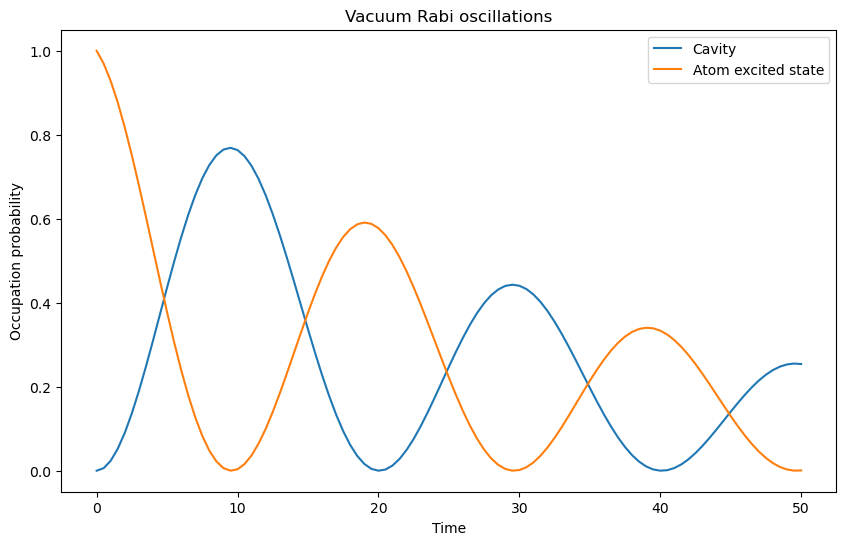

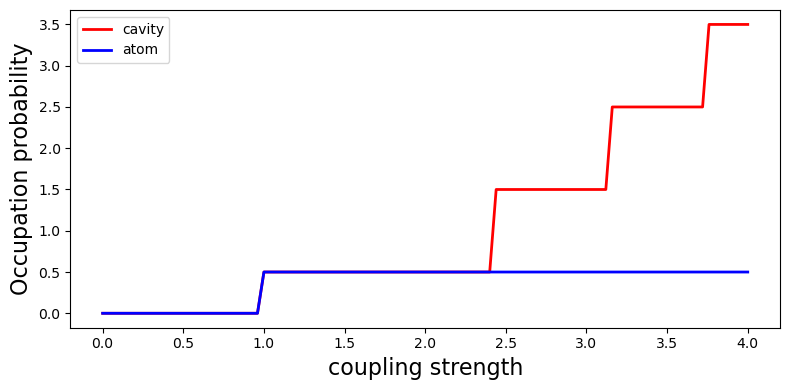

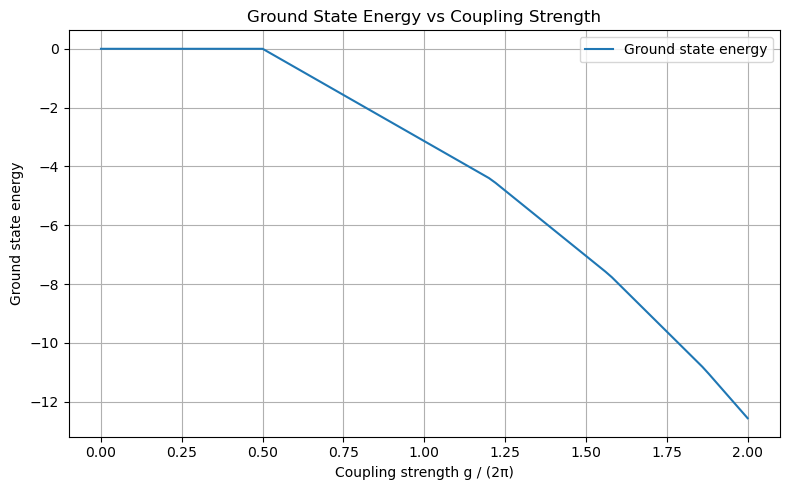

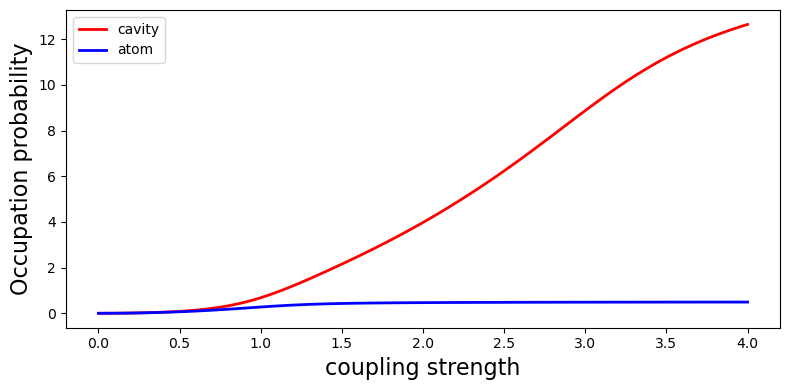

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from qutip import (basis,destroy,sesolve,qeye,tensor,mesolve,expect)

wc =  np.pi  
wa =  np.pi  
g = 0.05 * np.pi  
kappa = 0.005  # cavity dissipation rate
gamma = 0.05  # atom dissipation rate
N = 20  # number of cavity fock states
n_th_a = 0.0 

tlist = np.linspace(0, 50, 101)

psi0 = tensor(basis(N,0),basis(2,1))

a = tensor(destroy(N),qeye(2))
c = tensor(qeye(N),destroy(2))

H =  H = wc * a.dag() * a + wa * c.dag() * c + \
        g * (a.dag() * c + a * c.dag())

c_ops = []

# cavity relaxation
rate = kappa * (1 + n_th_a)
if rate > 0.0:
    c_ops.append(np.sqrt(rate) * a)

# cavity excitation, if temperature > 0
rate = kappa * n_th_a
if rate > 0.0:
    c_ops.append(np.sqrt(rate) * a.dag())

# qubit relaxation
rate = gamma
if rate > 0.0:
    c_ops.append(np.sqrt(rate) * c)

result = mesolve(H, psi0, tlist, c_ops, e_ops=[a.dag() * a, c.dag() * c])


n_c = result.expect[0]
n_a = result.expect[1]

fig, axes = plt.subplots(1, 1, figsize=(10, 6))

axes.plot(tlist, n_c, label="Cavity")
axes.plot(tlist, n_a, label="Atom excited state")
axes.legend(loc=0)
axes.set_xlabel("Time")
axes.set_ylabel("Occupation probability")
axes.set_title("Vacuum Rabi oscillations");

H0 = wc * a.dag() * a + wa * c.dag() * c

# interaction Hamiltonian
H1 = a.dag() * c + a * c.dag()


g_vec = np.linspace(0, 2.0, 101) * 2 * np.pi  # coupling strength vector

n_c_list = []
n_a_list = []
energy_list = []
for g in g_vec:
    H = H0 + g * H1
    gnd_energy, gnd_state = H.groundstate()
    
    # Expectation values in ground state
    n_c_list.append(expect(a.dag() * a, gnd_state))
    n_a_list.append(expect(c.dag() * c, gnd_state))
    energy_list.append(gnd_energy)

fig, axes = plt.subplots(1, 1, sharex=True, figsize=(8, 4))

axes.plot(g_vec / ( np.pi), n_c_list, "r", linewidth=2, label="cavity")
axes.plot(g_vec / ( np.pi), n_a_list, "b", linewidth=2, label="atom")
axes.set_ylabel("Occupation probability", fontsize=16)
axes.set_xlabel("coupling strength", fontsize=16)
axes.legend(loc=0)

fig.tight_layout()

plt.figure(figsize=(8, 5))
plt.plot(g_vec / (2 * np.pi), energy_list, label="Ground state energy")
plt.xlabel("Coupling strength g / (2π)")
plt.ylabel("Ground state energy")
plt.title("Ground State Energy vs Coupling Strength")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

H1 = H1 = (a.dag() + a) * (c + c.dag())


g_vec2 = np.linspace(0, 2.0, 101) * 2 * np.pi  # coupling strength vector

n_c_list2 = []
n_a_list2 = []

for g in g_vec2:
    H = H0 + g * H1
    gnd_energy2, gnd_state2 = H.groundstate()
    
    # Expectation values in ground state
    n_c_list2.append(expect(a.dag() * a, gnd_state2))
    n_a_list2.append(expect(c.dag() * c, gnd_state2))

fig, axes = plt.subplots(1, 1, sharex=True, figsize=(8, 4))

axes.plot(g_vec / ( np.pi), n_c_list2, "r", linewidth=2, label="cavity")
axes.plot(g_vec / ( np.pi), n_a_list2, "b", linewidth=2, label="atom")
axes.set_ylabel("Occupation probability", fontsize=16)
axes.set_xlabel("coupling strength", fontsize=16)
axes.legend(loc=0)

fig.tight_layout()

# Jaynes–Cummings Model at Finite Temperature

This code studies the Jaynes–Cummings model with cavity and atomic dissipation, now including thermal excitations via a nonzero average photon number $n_{\text{th}} = 2.0$.

---

## System Parameters

- $\omega_c = \omega_a = \pi$, $g = 0.05\pi$
- $\kappa = 0.005$, $\gamma = 0.05$
- Thermal photon number: $n_{\text{th}} = 2.0$
- Initial state: $|0\rangle \otimes |1\rangle$

---

## 1. Dissipative Dynamics with Thermal Photons

We simulate the system using `qutip.mesolve` with collapse operators for:

- Cavity decay and thermal excitation
- Atom decay

**Hamiltonian:**

$$
H = \omega_c a^\dagger a + \omega_a \sigma^\dagger \sigma + g(a^\dagger \sigma + a \sigma^\dagger)
$$

We plot occupation probabilities of the cavity and atom over time. Finite temperature leads to higher steady-state populations.

---

## 2. Ground State vs Coupling (RWA)

For varying $g$, we compute the ground state using:

$$
H = H_0 + g(a^\dagger \sigma + a \sigma^\dagger)
$$

We plot:

- $\langle a^\dagger a \rangle$
- $\langle \sigma^\dagger \sigma \rangle$
- Ground state energy

---

## 3. Beyond RWA Ground State

Using the full interaction:

$$
H = H_0 + g(a^\dagger + a)(\sigma + \sigma^\dagger)
$$

We compute how excitations shift in the ground state as $g$ increases.

---




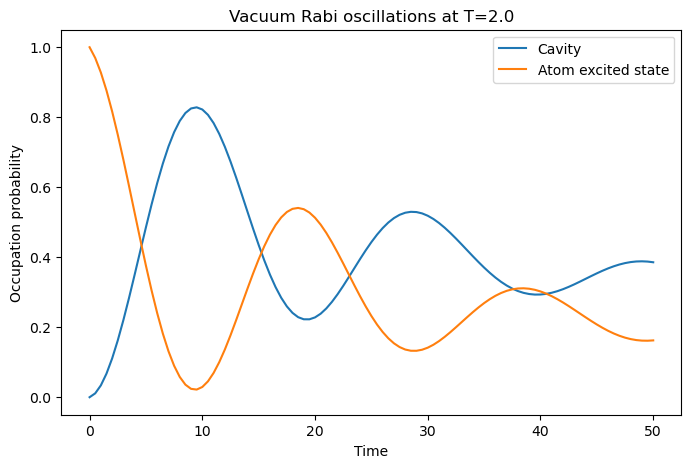

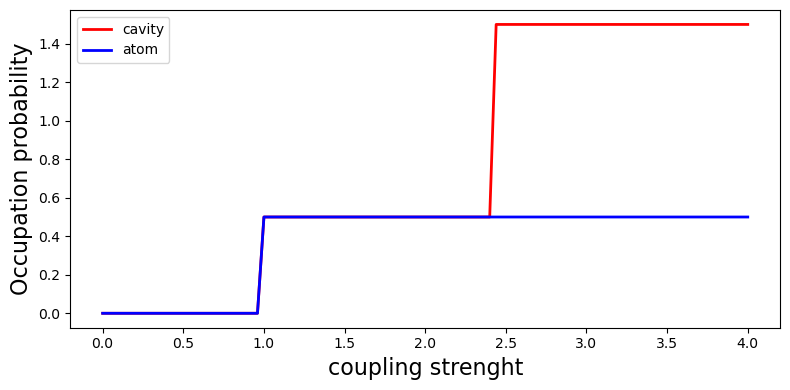

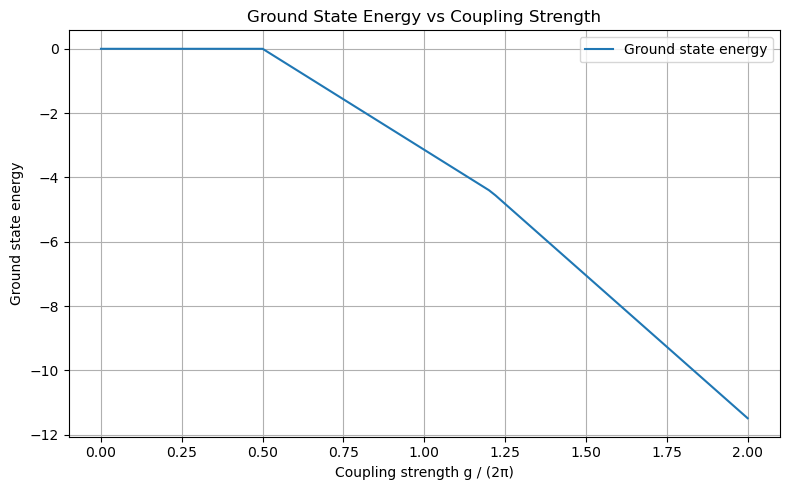

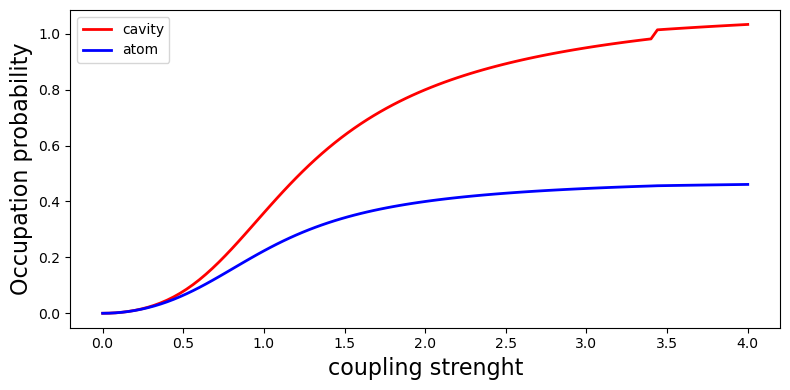

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from qutip import (basis,destroy,sesolve,qeye,tensor,mesolve)

wc =  np.pi  # cavity frequency
wa =  np.pi  # atom frequency
g = 0.05 * np.pi  # coupling strength
kappa = 0.005  # cavity dissipation rate
gamma = 0.05  # atom dissipation rate
N = 3  # number of cavity fock states
n_th_a = 2.0 

tlist = np.linspace(0, 50, 101)

psi0 = tensor(basis(N,0),basis(2,1))

a = tensor(destroy(N),qeye(2))
c = tensor(qeye(N),destroy(2))

H =  H = wc * a.dag() * a + wa * c.dag() * c + \
        g * (a.dag() * c + a * c.dag())

c_ops = []
n_th_a 
# cavity relaxation
rate = kappa * (1 + n_th_a)
if rate > 0.0:
    c_ops.append(np.sqrt(rate) * a)

# cavity excitation, if temperature > 0
rate = kappa * n_th_a
if rate > 0.0:
    c_ops.append(np.sqrt(rate) * a.dag())

# qubit relaxation
rate = gamma
if rate > 0.0:
    c_ops.append(np.sqrt(rate) * c)

# set collapse operators
c_op_list = []
rate = kappa * (1 + n_th_a)
c_op_list.append(np.sqrt(rate) * a)
rate = kappa * n_th_a
c_op_list.append(np.sqrt(rate) * a.dag())
rate = gamma
c_op_list.append(np.sqrt(rate) * c)

# evolve system
output_temp = mesolve(H, psi0, tlist, c_op_list, e_ops=[a.dag() * a, c.dag() * c])


# plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tlist, output_temp.expect[0], label="Cavity")
ax.plot(tlist, output_temp.expect[1], label="Atom excited state")
ax.legend()
ax.set_xlabel("Time")
ax.set_ylabel("Occupation probability")
ax.set_title("Vacuum Rabi oscillations at T={}".format(n_th_a));

H0 = wc * a.dag() * a + wa * c.dag() * c
H1 = a.dag() * c + a * c.dag()


g_vec = np.linspace(0, 2.0, 101) * 2 * np.pi  # coupling strength vector

n_c_list = []
n_a_list = []
energy_list = []
for g in g_vec:
    H = H0 + g * H1
    gnd_energy, gnd_state = H.groundstate()
    
    # Expectation values in ground state
    n_c_list.append(expect(a.dag() * a, gnd_state))
    n_a_list.append(expect(c.dag() * c, gnd_state))
    energy_list.append(gnd_energy)

fig, axes = plt.subplots(1, 1, sharex=True, figsize=(8, 4))

axes.plot(g_vec / ( np.pi), n_c_list, "r", linewidth=2, label="cavity")
axes.plot(g_vec / ( np.pi), n_a_list, "b", linewidth=2, label="atom")
axes.set_ylabel("Occupation probability", fontsize=16)
axes.set_xlabel("coupling strenght", fontsize=16)
axes.legend(loc=0)

fig.tight_layout()

plt.figure(figsize=(8, 5))
plt.plot(g_vec / (2 * np.pi), energy_list, label="Ground state energy")
plt.xlabel("Coupling strength g / (2π)")
plt.ylabel("Ground state energy")
plt.title("Ground State Energy vs Coupling Strength")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

H1 = H1 = (a.dag() + a) * (c + c.dag())


g_vec2 = np.linspace(0, 2.0, 101) * 2 * np.pi  # coupling strength vector

n_c_list2 = []
n_a_list2 = []

for g in g_vec2:
    H = H0 + g * H1
    gnd_energy2, gnd_state2 = H.groundstate()
    
    # Expectation values in ground state
    n_c_list2.append(expect(a.dag() * a, gnd_state2))
    n_a_list2.append(expect(c.dag() * c, gnd_state2))

fig, axes = plt.subplots(1, 1, sharex=True, figsize=(8, 4))

axes.plot(g_vec / ( np.pi), n_c_list2, "r", linewidth=2, label="cavity")
axes.plot(g_vec / ( np.pi), n_a_list2, "b", linewidth=2, label="atom")
axes.set_ylabel("Occupation probability", fontsize=16)
axes.set_xlabel("coupling strenght", fontsize=16)
axes.legend(loc=0)

fig.tight_layout()